In [1]:
from activation_funcs import *
from error_funcs import *
from initializer import *
from optimizer import *

from Model import MyModel
from layers import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
mnist = np.load("mnist.npz")
x_train, y_train = mnist['x_train'], mnist['y_train']
x_test, y_test = mnist['x_test'], mnist['y_test']

In [3]:
epoch = 10

In [4]:
def one_hot_encoding(label, max_num=10):
    tmp = [0 for i in range(max_num)]
    tmp[int(label)] = 1
    return tmp

def one_hot_decoding(label):
    return label.index(1)

In [5]:
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train = np.array([one_hot_encoding(i) for i in y_train])

In [6]:
affine_model = MyModel()

affine_model.add_layer(Flatten())
affine_model.add_layer(Affine(input_size=784, output_size=300, learning_rate=0.01))
affine_model.add_layer(Relu())
affine_model.add_layer(Affine(input_size=300, output_size=100, learning_rate=0.01))
affine_model.add_layer(Relu())
affine_model.add_layer(Affine(input_size=100, output_size=50, learning_rate=0.01))
affine_model.add_layer(Relu())
affine_model.add_layer(Affine(input_size=50, output_size=10, learning_rate=0.01))
affine_model.add_layer(Softmax())

affine_model.set_loss_func(func=CrossEntropyError())

In [7]:
affine_model.load_data(data_kind='train', x=x_train, y=y_train)
affine_model.data_batch_setting(setting_data='x_train', batch_size=100)
affine_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [8]:
affine_model.learn(epoch=epoch)

start epoch 1
Epoch 1 | Loss: 0.9130 | Accuracy: 0.7496
start epoch 2
Epoch 2 | Loss: 0.3635 | Accuracy: 0.8961
start epoch 3
Epoch 3 | Loss: 0.2937 | Accuracy: 0.9162
start epoch 4
Epoch 4 | Loss: 0.2558 | Accuracy: 0.9268
start epoch 5
Epoch 5 | Loss: 0.2288 | Accuracy: 0.9347
start epoch 6
Epoch 6 | Loss: 0.2076 | Accuracy: 0.9408
start epoch 7
Epoch 7 | Loss: 0.1902 | Accuracy: 0.9454
start epoch 8
Epoch 8 | Loss: 0.1755 | Accuracy: 0.9499
start epoch 9
Epoch 9 | Loss: 0.1629 | Accuracy: 0.9534
start epoch 10
Epoch 10 | Loss: 0.1520 | Accuracy: 0.9568


In [9]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test[i:i+batch_size]
    pred_raw = affine_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.9522


In [10]:
test_affine_model = MyModel()

test_affine_model.add_layer(Flatten())
test_affine_model.add_layer(Affine(input_size=784, output_size=300, learning_rate=0.15))
test_affine_model.add_layer(Relu())
test_affine_model.add_layer(Affine(input_size=300, output_size=100, learning_rate=0.10))
test_affine_model.add_layer(Relu())
test_affine_model.add_layer(Affine(input_size=100, output_size=50, learning_rate=0.05))
test_affine_model.add_layer(Relu())
test_affine_model.add_layer(Affine(input_size=50, output_size=10, learning_rate=0.01))
test_affine_model.add_layer(Softmax())

test_affine_model.set_loss_func(func=CrossEntropyError())

In [11]:
test_affine_model.load_data(data_kind='train', x=x_train, y=y_train)
test_affine_model.data_batch_setting(setting_data='x_train', batch_size=100)
test_affine_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [12]:
test_affine_model.learn(epoch=epoch)

start epoch 1
Epoch 1 | Loss: 0.3502 | Accuracy: 0.8984
start epoch 2
Epoch 2 | Loss: 0.1501 | Accuracy: 0.9564
start epoch 3
Epoch 3 | Loss: 0.1079 | Accuracy: 0.9688
start epoch 4
Epoch 4 | Loss: 0.0840 | Accuracy: 0.9760
start epoch 5
Epoch 5 | Loss: 0.0679 | Accuracy: 0.9812
start epoch 6
Epoch 6 | Loss: 0.0556 | Accuracy: 0.9845
start epoch 7
Epoch 7 | Loss: 0.0459 | Accuracy: 0.9876
start epoch 8
Epoch 8 | Loss: 0.0380 | Accuracy: 0.9903
start epoch 9
Epoch 9 | Loss: 0.0316 | Accuracy: 0.9924
start epoch 10
Epoch 10 | Loss: 0.0263 | Accuracy: 0.9942


In [13]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test[i:i+batch_size]
    pred_raw = test_affine_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.9753


In [14]:
affine_resnet_model = MyModel()
affine_resnet_model.add_layer(Flatten())
affine_resnet_model.add_layer(Affine_ResNet(size=784, learning_rate=0.01))
affine_resnet_model.add_layer(Relu())
affine_resnet_model.add_layer(Affine(input_size=784, output_size=100, learning_rate=0.01))
affine_resnet_model.add_layer(Relu())
affine_resnet_model.add_layer(Affine_ResNet(size=100, learning_rate=0.01))
affine_resnet_model.add_layer(Relu())
affine_resnet_model.add_layer(Affine(input_size=100, output_size=10, learning_rate=0.01))
affine_resnet_model.add_layer(Softmax())
affine_resnet_model.set_loss_func(CrossEntropyError())
affine_resnet_model.load_data(data_kind='train', x=x_train, y=y_train)
affine_resnet_model.data_batch_setting(setting_data='x_train', batch_size=100)
affine_resnet_model.data_batch_setting(setting_data='y_train', batch_size=100)
affine_resnet_model.learn(epoch=epoch)

start epoch 1
Epoch 1 | Loss: 0.5351 | Accuracy: 0.8501
start epoch 2
Epoch 2 | Loss: 0.2450 | Accuracy: 0.9287
start epoch 3
Epoch 3 | Loss: 0.1926 | Accuracy: 0.9444
start epoch 4
Epoch 4 | Loss: 0.1609 | Accuracy: 0.9533
start epoch 5
Epoch 5 | Loss: 0.1384 | Accuracy: 0.9605
start epoch 6
Epoch 6 | Loss: 0.1209 | Accuracy: 0.9657
start epoch 7
Epoch 7 | Loss: 0.1068 | Accuracy: 0.9698
start epoch 8
Epoch 8 | Loss: 0.0951 | Accuracy: 0.9736
start epoch 9
Epoch 9 | Loss: 0.0852 | Accuracy: 0.9766
start epoch 10
Epoch 10 | Loss: 0.0766 | Accuracy: 0.9790


In [15]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test[i:i+batch_size]
    pred_raw = affine_resnet_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.9686


In [16]:
cnn_model = MyModel()

cnn_model.add_layer(Conv(filter_num=10, filter_channels=1, filter_height=3, filter_width=3, stride=1, pad=1, learning_rate=0.01)) # 28x28 
cnn_model.add_layer(Relu())
cnn_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0)) # 14x14 -> (N, C, H, W) = (batch, 10, 14, 14)
cnn_model.add_layer(Conv(filter_num=10, filter_channels=10, filter_height=3, filter_width=3, stride=1, pad=1, learning_rate=0.01)) # 14x14
cnn_model.add_layer(Relu())
cnn_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0)) # 7x7 -> (N, C, H, W) = (batch, 10, 7, 7)
cnn_model.add_layer(Flatten())
cnn_model.add_layer(Affine(input_size=490, output_size=50, learning_rate=0.01)) # 10*7x7=490
cnn_model.add_layer(Relu())
cnn_model.add_layer(Affine(input_size=50, output_size=10, learning_rate=0.01))
cnn_model.add_layer(Softmax())

cnn_model.set_loss_func(func=CrossEntropyError())

In [17]:
x_train_cnn = x_train.reshape(-1, 1, 28, 28)
x_test_cnn = x_test.reshape(-1, 1, 28, 28)
cnn_model.load_data(data_kind='train', x=x_train_cnn, y=y_train)
cnn_model.data_batch_setting(setting_data='x_train', batch_size=100)
cnn_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [18]:
cnn_model.learn(epoch=10)

start epoch 1
Epoch 1 | Loss: 0.7846 | Accuracy: 0.7631
start epoch 2
Epoch 2 | Loss: 0.3146 | Accuracy: 0.9043
start epoch 3
Epoch 3 | Loss: 0.2415 | Accuracy: 0.9280
start epoch 4
Epoch 4 | Loss: 0.1976 | Accuracy: 0.9411
start epoch 5
Epoch 5 | Loss: 0.1674 | Accuracy: 0.9500
start epoch 6
Epoch 6 | Loss: 0.1452 | Accuracy: 0.9567
start epoch 7
Epoch 7 | Loss: 0.1287 | Accuracy: 0.9610
start epoch 8
Epoch 8 | Loss: 0.1158 | Accuracy: 0.9650
start epoch 9
Epoch 9 | Loss: 0.1058 | Accuracy: 0.9682
start epoch 10
Epoch 10 | Loss: 0.0980 | Accuracy: 0.9706


In [19]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test_cnn[i:i+batch_size]
    pred_raw = cnn_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.9709


In [26]:
resnet_model = MyModel()

resnet_model.add_layer(Conv(filter_num=10, filter_channels=1, filter_height=3, filter_width=3))
resnet_model.add_layer(Relu())
resnet_model.add_layer(ResidualBlock(10, 3, 3))
resnet_model.add_layer(Relu())
resnet_model.add_layer(ResidualBlock(10, 3, 3))
resnet_model.add_layer(Relu())
resnet_model.add_layer(Pooling(pool_h=2, pool_w=2, stride=2, pad=0))
resnet_model.add_layer(Flatten())
resnet_model.add_layer(Affine(input_size=1690, output_size=10)) # 사이즈 연산 과정은 아래 주석 참고
resnet_model.add_layer(Softmax())

resnet_model.set_loss_func(func=CrossEntropyError())

In [27]:
resnet_model.load_data(data_kind='train', x=x_train_cnn, y=y_train)
resnet_model.data_batch_setting(setting_data='x_train', batch_size=100)
resnet_model.data_batch_setting(setting_data='y_train', batch_size=100)

In [28]:
resnet_model.learn(epoch=10)

start epoch 1
Epoch 1 | Loss: 0.4078 | Accuracy: 0.8758
start epoch 2
Epoch 2 | Loss: 0.1662 | Accuracy: 0.9516
start epoch 3
Epoch 3 | Loss: 0.1086 | Accuracy: 0.9688
start epoch 4
Epoch 4 | Loss: 0.0854 | Accuracy: 0.9752
start epoch 5
Epoch 5 | Loss: 0.0730 | Accuracy: 0.9784
start epoch 6
Epoch 6 | Loss: 0.0649 | Accuracy: 0.9806
start epoch 7
Epoch 7 | Loss: 0.0589 | Accuracy: 0.9822
start epoch 8
Epoch 8 | Loss: 0.0543 | Accuracy: 0.9836
start epoch 9
Epoch 9 | Loss: 0.0505 | Accuracy: 0.9848
start epoch 10
Epoch 10 | Loss: 0.0473 | Accuracy: 0.9857


In [30]:
predict_labels = []
batch_size = 100
for i in range(0, len(x_test), batch_size):
    x_batch = x_test_cnn[i:i+batch_size]
    pred_raw = resnet_model.predict(x_batch)
    pred_label = np.argmax(pred_raw, axis=1)
    predict_labels.extend(pred_label)

predict_labels = np.array(predict_labels)
accuracy = np.sum(predict_labels == y_test) / len(y_test)
print(f"test accuracy: {accuracy:.4f}")

test accuracy: 0.9809


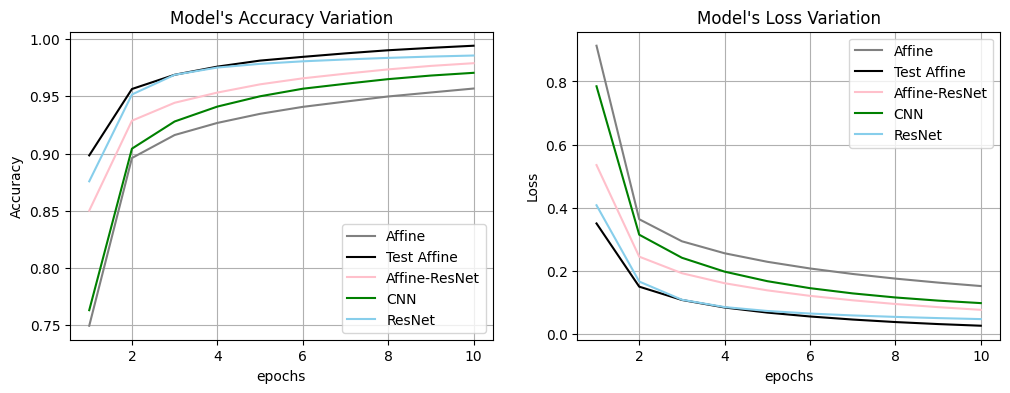

In [31]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.plot([i+1 for i in range(epoch)], affine_model.acc_log, label='Affine', color='gray')
ax1.plot([i+1 for i in range(epoch)], test_affine_model.acc_log, label='Test Affine', color='black')
ax1.plot([i+1 for i in range(epoch)], affine_resnet_model.acc_log, label='Affine-ResNet', color='pink')
ax1.plot([i+1 for i in range(epoch)], cnn_model.acc_log, label='CNN', color='green')
ax1.plot([i+1 for i in range(epoch)], resnet_model.acc_log, label='ResNet', color='skyblue')
ax1.set_title("Model's Accuracy Variation")
ax1.set_xlabel("epochs")
ax1.set_ylabel("Accuracy")
ax1.grid()
ax1.legend()

ax2.plot([i+1 for i in range(epoch)], affine_model.loss_log, label='Affine', color='gray')
ax2.plot([i+1 for i in range(epoch)], test_affine_model.loss_log, label='Test Affine', color='black')
ax2.plot([i+1 for i in range(epoch)], affine_resnet_model.loss_log, label='Affine-ResNet', color='pink')
ax2.plot([i+1 for i in range(epoch)], cnn_model.loss_log, label='CNN', color='green')
ax2.plot([i+1 for i in range(epoch)], resnet_model.loss_log, label='ResNet', color='skyblue')
ax2.set_title("Model's Loss Variation")
ax2.set_xlabel("epochs")
ax2.set_ylabel("Loss")
ax2.grid()
ax2.legend()

plt.show()